In [1]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import json
import os
from pathlib import Path
import matplotlib as mpl
from matplotlib.offsetbox import AnchoredText
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from experiments.configs.classification_consts import MODELS
plt.rcParams['text.usetex'] = False
# plt.rcParams.update({
#     "text.usetex": True,              # Use TeX for text rendering
#     "font.family": "serif",
#     "hatch.color": "white"
# })
%load_ext autoreload
%autoreload 2

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import log_loss
from src.PCS.classification.multi_class_jucal import MultiClassPCS_JUCAL, make_splits
from experiments.configs.classification_configs import get_classification_datasets
from src.metrics.classification_metrics import get_uncertainties

# from sklearn.linear_model import LogisticRegression
# from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
# from xgboost import XGBClassifier

In [3]:
DATASETS = ["data_yeast"]
RESULT_PATH = Path('../results/ablation/boot')

In [ ]:
seed = 42

In [ ]:
dataset_key = 0
X, y, _, importance = get_classification_datasets(DATASETS[dataset_key])

num_classes = len(np.unique(y))
sample_proportions = [0.0625, 0.125, 0.25, 0.5, 1]

subsets_ = make_splits(np.array(range(len(y))), y, [0.75], seed=3*seed)
train_inds = subsets_[0.75]
test_inds = np.setdiff1d(range(len(y)), train_inds)

ytest = y[test_inds]

assert len(np.unique(y)) == len(np.unique(ytest))

subsets = make_splits(train_inds, y, sample_proportions, seed=2*seed)


C1_mat = np.full(shape=(len(sample_proportions), len(importance)), fill_value=None)
C2_mat = np.full(shape=(len(sample_proportions), len(importance)), fill_value=None)
aleatoric_mat = np.full(shape=(len(sample_proportions), len(importance)), fill_value=None)
epistemic_mat = np.full(shape=(len(sample_proportions), len(importance)), fill_value=None)
NLL_mat = np.full(shape=(len(sample_proportions), len(importance)), fill_value=None)

for (i, sample_proportion) in enumerate(sample_proportions):
    for j in range(len(importance)):

        print(sample_proportion, j+1)
        save_path = f"./models/{DATASETS[dataset_key]}/seed_{seed}/fill/sample_proportion_{sample_proportion}_num_features_{j+1}"

        Xtrain = (X[importance.iloc[0:j+1]["feature"]].to_numpy())[subsets[sample_proportion]]
        Xtest = (X[importance.iloc[0:j+1]["feature"]].to_numpy())[test_inds]

        assert len(np.unique(y)) == len(np.unique(y[subsets[sample_proportion]]))
        assert not (set(test_inds) & set(subsets[sample_proportion]))
        

        pcs_JUCAL = MultiClassPCS_JUCAL(
            MODELS,
            num_bootstraps=500,
            n_classes=len(np.unique(y)),
            seed=seed,
            top_k=2,
            save_path=save_path,
            load_models=True,
            metric=log_loss,
            calibration_method="jucal",
        )
        pcs_JUCAL.fit(Xtrain, y[subsets[sample_proportion]], fill=True)
        ensemble = pcs_JUCAL.ensemble(Xtest)

        C1_mat[i, j] = pcs_JUCAL.c1
        C2_mat[i, j] = pcs_JUCAL.c2

        Uepistemic, Ualeatoric = get_uncertainties(ensemble)
        epistemic_mat[i, j] = Uepistemic
        aleatoric_mat[i, j] = Ualeatoric 

        probas = np.nanmean(ensemble, axis=2)
        NLL_mat[i, j] = pcs_JUCAL.metric(ytest, probas, labels=range(num_classes))

        print("==========================================================")

0.25 1
Loading models from ./models/data_yeast/nan_fill/sample_proportion_0.25_num_features_1


Training LogisticRegression models: 100%|██████████| 500/500 [00:00<00:00, 4293.25it/s]


Finished training LogisticRegression models


Training MLP models: 100%|██████████| 500/500 [00:00<00:00, 2062.20it/s]


Finished training MLP models
Calibrating models


...

Training RandomForest models: 100%|██████████| 500/500 [00:01<00:00, 433.77it/s]


Finished training RandomForest models


Training MLP models: 100%|██████████| 500/500 [00:00<00:00, 2015.33it/s]


Finished training MLP models
Calibrating models


1000it [00:17, 58.80it/s]
1000it [00:07, 134.24it/s]


In [5]:
epistemic_avgs = np.full(shape=(len(sample_proportions), len(importance)), fill_value=None)
for i in range(len(sample_proportions)):
    for j in range(len(importance)):
        epistemic_avgs[i, j] = np.mean(epistemic_mat[i, j])

In [6]:
aleatoric_avgs = np.full(shape=(len(sample_proportions), len(importance)), fill_value=None)
for i in range(len(sample_proportions)):
    for j in range(len(importance)):
        aleatoric_avgs[i, j] = np.mean(aleatoric_mat[i, j])

[Text(0.5, 0, '1'),
 Text(1.5, 0, '2'),
 Text(2.5, 0, '3'),
 Text(3.5, 0, '4'),
 Text(4.5, 0, '5'),
 Text(5.5, 0, '6'),
 Text(6.5, 0, '7'),
 Text(7.5, 0, '8')]

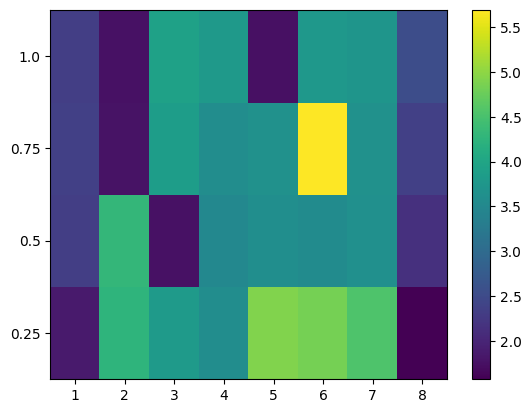

In [7]:
fig, ax = plt.subplots()
heatmap = ax.pcolor(np.float64(NLL_mat))
plt.colorbar(heatmap)
row_labels = sample_proportions
col_labels = range(1, len(importance)+1)

ax.set_yticks(np.arange(NLL_mat.shape[0])+0.5, minor=False)
ax.set_xticks(np.arange(NLL_mat.shape[1])+0.5, minor=False)

ax.set_yticklabels(row_labels, minor=False)
ax.set_xticklabels(col_labels, minor=False)

[Text(0.5, 0, '1'),
 Text(1.5, 0, '2'),
 Text(2.5, 0, '3'),
 Text(3.5, 0, '4'),
 Text(4.5, 0, '5'),
 Text(5.5, 0, '6'),
 Text(6.5, 0, '7'),
 Text(7.5, 0, '8')]

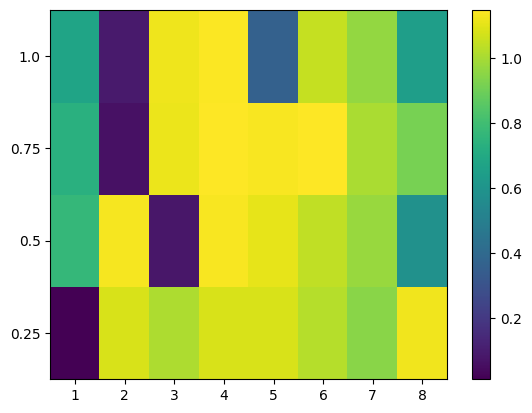

In [8]:
fig, ax = plt.subplots()
heatmap = ax.pcolor(np.float64(epistemic_avgs))
plt.colorbar(heatmap)
row_labels = sample_proportions
col_labels = range(1, len(importance)+1)

ax.set_yticks(np.arange(epistemic_avgs.shape[0])+0.5, minor=False)
ax.set_xticks(np.arange(epistemic_avgs.shape[1])+0.5, minor=False)

ax.set_yticklabels(row_labels, minor=False)
ax.set_xticklabels(col_labels, minor=False)

[Text(0.5, 0, '1'),
 Text(1.5, 0, '2'),
 Text(2.5, 0, '3'),
 Text(3.5, 0, '4'),
 Text(4.5, 0, '5'),
 Text(5.5, 0, '6'),
 Text(6.5, 0, '7'),
 Text(7.5, 0, '8')]

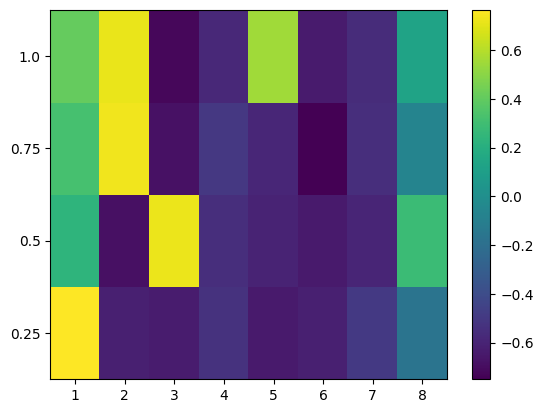

In [9]:
fig, ax = plt.subplots()
heatmap = ax.pcolor(np.log(np.float64(aleatoric_avgs)))
plt.colorbar(heatmap)
row_labels = sample_proportions
col_labels = range(1, len(importance)+1)

ax.set_yticks(np.arange(aleatoric_avgs.shape[0])+0.5, minor=False)
ax.set_xticks(np.arange(aleatoric_avgs.shape[1])+0.5, minor=False)

ax.set_yticklabels(row_labels, minor=False)
ax.set_xticklabels(col_labels, minor=False)

[Text(0.5, 0, '1'),
 Text(1.5, 0, '2'),
 Text(2.5, 0, '3'),
 Text(3.5, 0, '4'),
 Text(4.5, 0, '5'),
 Text(5.5, 0, '6'),
 Text(6.5, 0, '7'),
 Text(7.5, 0, '8')]

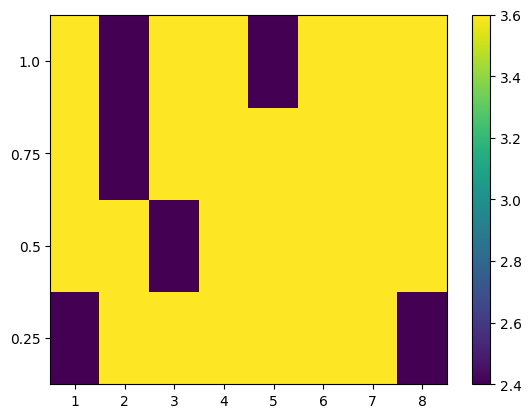

In [10]:
fig, ax = plt.subplots()
heatmap = ax.pcolor(np.float64(C1_mat))
plt.colorbar(heatmap)
row_labels = sample_proportions
col_labels = range(1, len(importance)+1)

ax.set_yticks(np.arange(C1_mat.shape[0])+0.5, minor=False)
ax.set_xticks(np.arange(C1_mat.shape[1])+0.5, minor=False)

ax.set_yticklabels(row_labels, minor=False)
ax.set_xticklabels(col_labels, minor=False)

[Text(0.5, 0, '1'),
 Text(1.5, 0, '2'),
 Text(2.5, 0, '3'),
 Text(3.5, 0, '4'),
 Text(4.5, 0, '5'),
 Text(5.5, 0, '6'),
 Text(6.5, 0, '7'),
 Text(7.5, 0, '8')]

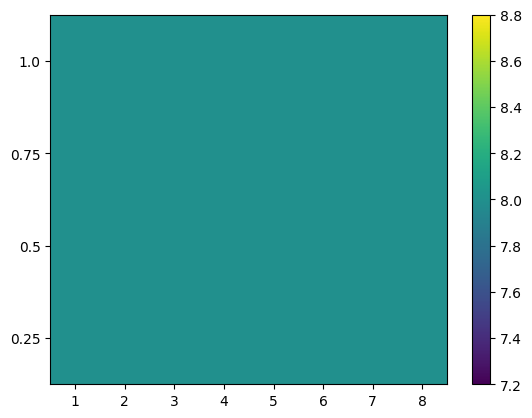

In [11]:
fig, ax = plt.subplots()
heatmap = ax.pcolor(np.float64(C2_mat))
plt.colorbar(heatmap)
row_labels = sample_proportions
col_labels = range(1, len(importance)+1)

ax.set_yticks(np.arange(C2_mat.shape[0])+0.5, minor=False)
ax.set_xticks(np.arange(C2_mat.shape[1])+0.5, minor=False)

ax.set_yticklabels(row_labels, minor=False)
ax.set_xticklabels(col_labels, minor=False)